# COT Commercial Positioning Signal

## Hypothesis
Commercial producers/merchants (PMPU category in CFTC disaggregated report) going unusually 
long in physical commodities signals future price appreciation. Conversely, unusually short 
positioning signals future price decline.

The signal is the percentile rank of commercial net positioning over a rolling window, 
optionally filtered by a price trend condition.

## Signal Universe
Physical commodities only (no equity indices, no treasuries). The commercial hedger 
informational edge is strongest where producers have direct knowledge of supply/demand 
fundamentals.

## Key Methodological Notes
- Non-overlapping forward return windows for conditional analysis (avoid inflated significance)
- Exact Spearman rank correlation for IC (not Pearson on ranks)
- In-sample (pre-2016) / out-of-sample (2016+) split
- Both long and short signals tested

## Research Degrees of Freedom
| Choice | Variants tested |
|---|---|
| Positioning measure | 2 (raw net, OI-normalized) |
| Lookback window | 4 (26w, 52w, 78w, 104w) |
| Threshold | 3 (90th, 95th, 100th pctile) |
| Trend filter | 4 (none, MA cross, price>MA, momentum) |
| Forward return horizon | 5 (1w, 2w, 4w, 8w, 12w) |
| Direction | 2 (long, short) |

Total: 960 configurations before regime splits. Nominal p-values and t-stats
are not adjusted for this search. The IS/OOS split is the primary overfitting control,
but variant selection used full-sample IC — treat OOS results as promising evidence,
not clean validation.

## 1. Data Loading & Validation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pathlib
import sys

# ── Navigate to project root (notebook lives at notebooks/signals/) ───────────
_root = pathlib.Path.cwd()
for _ in range(4):
    if (_root / 'src').is_dir() and (_root / 'data').is_dir():
        break
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
print(f"Working directory : {pathlib.Path.cwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from dotenv import load_dotenv
load_dotenv()

from src.db.client import db
db.open()

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
sns.set_style('whitegrid')

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)
print('Setup complete.')

# ---------------------------------------------------------------------------
# COT disaggregated data
# ---------------------------------------------------------------------------
rows = db.query("""
    SELECT
        cp.report_date,
        cp.series_id,
        ms.code   AS series_code,
        ms.name   AS series_name,
        cp.open_interest,
        cp.dis_pmpu_long,
        cp.dis_pmpu_short
    FROM cot_positions cp
    JOIN macro_series ms ON cp.series_id = ms.id
    WHERE cp.report_type = 'disagg_fut'
""")

cot_raw = pd.DataFrame(rows)
cot_raw['report_date'] = pd.to_datetime(cot_raw['report_date'])

print(f"\ncot_raw shape: {cot_raw.shape}")
print("\nDistinct COT series (series_code, series_name) — sorted:")
print(
    cot_raw[['series_code', 'series_name']]
    .drop_duplicates()
    .sort_values('series_code')
    .to_string(index=False)
)

# ---------------------------------------------------------------------------
# Commodity prices
# ---------------------------------------------------------------------------
rows = db.query("""
    SELECT
        a.id     AS asset_id,
        a.ticker,
        CAST(p.timestamp AS DATE) AS timestamp,
        p.close
    FROM prices p
    JOIN assets a ON p.asset_id = a.id
    WHERE a.asset_class = 'futures'
      AND p.interval    = '1d'
    ORDER BY a.ticker, timestamp
""")

prices_raw = pd.DataFrame(rows)
prices_raw['timestamp'] = pd.to_datetime(prices_raw['timestamp'])

print(f"\nprices_raw shape: {prices_raw.shape}")
print("\nDistinct tickers with date ranges and row counts:")
print(
    prices_raw.groupby('ticker')['timestamp']
    .agg(min_date='min', max_date='max', rows='count')
    .sort_index()
    .to_string()
)

# ---------------------------------------------------------------------------
# Commodity mapping
# ---------------------------------------------------------------------------
# fmt: off
COMMODITY_MAP = {
    "Crude Oil":   {"cot_code": "CFTC.DISAGG_FUT.067651", "price_ticker": "CL1"},
    "Natural Gas": {"cot_code": "CFTC.DISAGG_FUT.023651", "price_ticker": "NG1"},
    "Gold":        {"cot_code": "CFTC.DISAGG_FUT.088691", "price_ticker": "GC1"},
    "Silver":      {"cot_code": "CFTC.DISAGG_FUT.084691", "price_ticker": "SI1"},
    "Copper":      {"cot_code": "CFTC.DISAGG_FUT.085692", "price_ticker": "HG1"},
    "Corn":        {"cot_code": "CFTC.DISAGG_FUT.002602", "price_ticker": "ZC1"},
    "Wheat":       {"cot_code": "CFTC.DISAGG_FUT.001602", "price_ticker": "ZW1"},
    "Soybeans":    {"cot_code": "CFTC.DISAGG_FUT.005602", "price_ticker": "ZS1"},
    "Coffee":      {"cot_code": "CFTC.DISAGG_FUT.083731", "price_ticker": "KC1"},
    "Sugar":       {"cot_code": "CFTC.DISAGG_FUT.080732", "price_ticker": "SB1"},
    "Cocoa":       {"cot_code": "CFTC.DISAGG_FUT.073732", "price_ticker": "CC1"},
}
# fmt: on

# ---------------------------------------------------------------------------
# Coverage validation
# ---------------------------------------------------------------------------
MIN_OVERLAP_WEEKS = 260  # 5 years

cot_dates   = cot_raw.groupby('series_code')['report_date'].agg(min='min', max='max')
price_dates = prices_raw.groupby('ticker')['timestamp'].agg(min='min', max='max')

coverage_rows = []
warnings_list = []

for name, cfg in COMMODITY_MAP.items():
    cot_code = cfg['cot_code']
    ticker   = cfg['price_ticker']

    # COT stats
    if cot_code in cot_dates.index:
        cot_min  = cot_dates.loc[cot_code, 'min']
        cot_max  = cot_dates.loc[cot_code, 'max']
        cot_rows = (cot_raw['series_code'] == cot_code).sum()
    else:
        cot_min = cot_max = pd.NaT
        cot_rows = 0

    # Price stats
    if ticker in price_dates.index:
        px_min  = price_dates.loc[ticker, 'min']
        px_max  = price_dates.loc[ticker, 'max']
        px_rows = (prices_raw['ticker'] == ticker).sum()
    else:
        px_min = px_max = pd.NaT
        px_rows = 0

    # Overlap
    if pd.notna(cot_min) and pd.notna(px_min):
        overlap_start = max(cot_min, px_min)
        overlap_end   = min(cot_max, px_max)
        if overlap_end >= overlap_start:
            overlap_weeks = int((overlap_end - overlap_start).days / 7)
        else:
            overlap_start = overlap_end = pd.NaT
            overlap_weeks = 0
    else:
        overlap_start = overlap_end = pd.NaT
        overlap_weeks = 0

    flag = ' ⚠ SHORT' if overlap_weeks < MIN_OVERLAP_WEEKS else ''
    if flag:
        warnings_list.append(name)

    coverage_rows.append({
        'Commodity':     name,
        'COT rows':      cot_rows,
        'COT start':     cot_min.date() if pd.notna(cot_min) else 'MISSING',
        'COT end':       cot_max.date() if pd.notna(cot_max) else 'MISSING',
        'Price rows':    px_rows,
        'Price start':   px_min.date()  if pd.notna(px_min)  else 'MISSING',
        'Price end':     px_max.date()  if pd.notna(px_max)  else 'MISSING',
        'Overlap start': overlap_start.date() if pd.notna(overlap_start) else 'NONE',
        'Overlap end':   overlap_end.date()   if pd.notna(overlap_end)   else 'NONE',
        'Overlap wks':   f"{overlap_weeks}{flag}",
    })

coverage_df = pd.DataFrame(coverage_rows)
print("\n--- Per-Commodity Coverage ---")
print(coverage_df.to_string(index=False))

if warnings_list:
    print(f"\n⚠  Commodities with < {MIN_OVERLAP_WEEKS} weeks overlap: {warnings_list}")
else:
    print(f"\n✓  All commodities have ≥ {MIN_OVERLAP_WEEKS} weeks of overlapping data.")

# ---------------------------------------------------------------------------
# Overall coverage summary
# ---------------------------------------------------------------------------
print("\n--- Coverage Summary ---")
print(f"COT data:   {cot_raw['report_date'].min().date()} → {cot_raw['report_date'].max().date()}  ({len(cot_raw):,} rows)")
print(f"Price data: {prices_raw['timestamp'].min().date()} → {prices_raw['timestamp'].max().date()}  ({len(prices_raw):,} rows)")


Working directory : /Users/rhlbh/projects/claudeProjects/quant


2026-05-10 11:43:45 [INFO] Opening DuckDB at data/quant.db
2026-05-10 11:43:45 [INFO] DB schema up to date (version 7)


Setup complete.

cot_raw shape: (20966, 7)

Distinct COT series (series_code, series_name) — sorted:
           series_code                                                    series_name
CFTC.DISAGG_FUT.001602                                 WHEAT - CHICAGO BOARD OF TRADE
CFTC.DISAGG_FUT.002602                                  CORN - CHICAGO BOARD OF TRADE
CFTC.DISAGG_FUT.005602                              SOYBEANS - CHICAGO BOARD OF TRADE
CFTC.DISAGG_FUT.023651                     NATURAL GAS - NEW YORK MERCANTILE EXCHANGE
CFTC.DISAGG_FUT.067651          CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE EXCHANGE
CFTC.DISAGG_FUT.073732                                COCOA - NEW YORK BOARD OF TRADE
CFTC.DISAGG_FUT.080732                         SUGAR NO. 11 - NEW YORK BOARD OF TRADE
CFTC.DISAGG_FUT.083731                             COFFEE C - NEW YORK BOARD OF TRADE
CFTC.DISAGG_FUT.084691                               SILVER - COMMODITY EXCHANGE INC.
CFTC.DISAGG_FUT.085692                 

## 2. Signal Construction

In [2]:

from scipy.stats import percentileofscore

# ── 1. Filter to target commodities ──────────────────────────────────────────
code_to_commodity = {cfg['cot_code']: name for name, cfg in COMMODITY_MAP.items()}

cot = cot_raw[cot_raw['series_code'].isin(code_to_commodity)].copy()
cot['commodity'] = cot['series_code'].map(code_to_commodity)

# Net contracts (raw) and OI-normalised
cot['net_long']    = cot['dis_pmpu_long'] - cot['dis_pmpu_short']
cot['net_long_oi'] = (cot['net_long'] / cot['open_interest']).replace([np.inf, -np.inf], np.nan)

cot = cot.sort_values(['commodity', 'report_date']).reset_index(drop=True)

print(f"cot shape: {cot.shape}")
print("\nRows per commodity:")
print(cot['commodity'].value_counts().sort_index())


# ── 2. Rolling percentile ranks ───────────────────────────────────────────────
WINDOWS = [26, 52, 78, 104]  # weeks

def rolling_pctile(s: pd.Series, window: int) -> pd.Series:
    """Percentile rank of current obs vs prior window obs (x[-1] vs x[:-1])."""
    return s.rolling(window, min_periods=window // 2).apply(
        lambda x: percentileofscore(x[:-1], x[-1], kind='rank'),
        raw=True,
    )

pieces = []
for commodity, grp in cot.groupby('commodity', sort=True):
    grp = grp.sort_values('report_date').copy()
    for w in WINDOWS:
        grp[f'raw_pctile_{w}w'] = rolling_pctile(grp['net_long'],    w)
        grp[f'oi_pctile_{w}w']  = rolling_pctile(grp['net_long_oi'], w)
    pieces.append(grp)

cot = pd.concat(pieces).sort_values(['commodity', 'report_date']).reset_index(drop=True)

# ── 3. Summary statistics ─────────────────────────────────────────────────────
# Table 1: non-NaN counts for raw_pctile_52w
print("\n--- Non-NaN counts for raw_pctile_52w (expect ≈ total_rows − 26) ---")
counts = (
    cot.groupby('commodity')['raw_pctile_52w']
    .apply(lambda s: s.notna().sum())
    .rename('non_nan')
    .to_frame()
)
counts['total_rows'] = cot.groupby('commodity').size()
counts['expected']   = counts['total_rows'] - 26
print(counts.to_string())

# Table 2: signal trigger counts at thresholds 90, 95, 100
signal_cols = [f'raw_pctile_{w}w' for w in WINDOWS] + [f'oi_pctile_{w}w' for w in WINDOWS]
thresholds  = [90, 95, 100]

print("\n--- Signal trigger counts (rows where signal > threshold) ---")
print("  Note: '100' means current value is at the rolling maximum\n")
trigger_df = pd.DataFrame(
    {thr: {col: (cot[col] >= thr).sum() for col in signal_cols} for thr in thresholds},
    index=signal_cols,
).rename(columns={thr: f'≥{thr}' for thr in thresholds})
print(trigger_df.to_string())


cot shape: (11429, 10)

Rows per commodity:
commodity
Cocoa          1039
Coffee         1039
Copper         1039
Corn           1039
Crude Oil      1039
Gold           1039
Natural Gas    1039
Silver         1039
Soybeans       1039
Sugar          1039
Wheat          1039
Name: count, dtype: int64

--- Non-NaN counts for raw_pctile_52w (expect ≈ total_rows − 26) ---
             non_nan  total_rows  expected
commodity                                 
Cocoa           1014        1039      1013
Coffee          1014        1039      1013
Copper          1014        1039      1013
Corn            1014        1039      1013
Crude Oil       1014        1039      1013
Gold            1014        1039      1013
Natural Gas     1014        1039      1013
Silver          1014        1039      1013
Soybeans        1014        1039      1013
Sugar           1014        1039      1013
Wheat           1014        1039      1013

--- Signal trigger counts (rows where signal > threshold) ---
  Note: 

## 3. Trend Filter

In [3]:

# COT data: positions as-of Tuesday, released Friday afternoon.
# Entry at next Monday close ensures the data is fully public before trading.
# This is conservative but realistic for a weekly-frequency signal.

# ── 1. Resample daily prices → weekly (Monday close) ─────────────────────────
ticker_to_commodity = {cfg['price_ticker']: name for name, cfg in COMMODITY_MAP.items()}
target_tickers = set(ticker_to_commodity)

px = prices_raw[prices_raw['ticker'].isin(target_tickers)].copy()
px['timestamp'] = pd.to_datetime(px['timestamp'])

weekly_pieces = []
for ticker, grp in px.groupby('ticker'):
    weekly = (
        grp.set_index('timestamp')['close']
        .resample('W-MON')
        .last()
        .dropna()
        .reset_index()
        .rename(columns={'timestamp': 'week_date'})
    )
    weekly['commodity'] = ticker_to_commodity[ticker]
    weekly_pieces.append(weekly[['commodity', 'week_date', 'close']])

prices_weekly = pd.concat(weekly_pieces).sort_values(['commodity', 'week_date']).reset_index(drop=True)
print(f"prices_weekly shape: {prices_weekly.shape}")
print(prices_weekly.groupby('commodity')['week_date'].agg(min='min', max='max', weeks='count'))


# ── 2. Compute trend filters ──────────────────────────────────────────────────
trend_pieces = []
for commodity, grp in prices_weekly.groupby('commodity', sort=True):
    grp = grp.sort_values('week_date').copy()
    sma10 = grp['close'].rolling(10,  min_periods=10).mean()
    sma40 = grp['close'].rolling(40,  min_periods=40).mean()
    ret12 = grp['close'] / grp['close'].shift(12) - 1

    grp['trend_ma_cross']       = sma10 > sma40
    grp['trend_price_above_ma'] = grp['close'] > sma40
    grp['trend_momentum']       = ret12 > 0
    grp['trend_none']           = True
    trend_pieces.append(grp)

prices_weekly = pd.concat(trend_pieces).sort_values(['commodity', 'week_date']).reset_index(drop=True)


# ── 3. Merge trend filters onto COT signal DataFrame ─────────────────────────
# Entry = next Monday close after COT publication (Friday release)
# report_date is Tuesday; next Monday = +6 days
cot['week_date'] = cot['report_date'] + pd.to_timedelta(
    (7 - cot['report_date'].dt.weekday) % 7, unit='D'
)

trend_cols = ['commodity', 'week_date', 'trend_ma_cross', 'trend_price_above_ma',
              'trend_momentum', 'trend_none']

cot = cot.merge(prices_weekly[trend_cols], on=['commodity', 'week_date'], how='left')

unmatched = cot[['trend_ma_cross', 'trend_price_above_ma', 'trend_momentum']].isna().any(axis=1).sum()
print(f"\nMerge result: {len(cot):,} rows total, {unmatched:,} unmatched (NaN in any trend column)")


# ── 4. Filter-on fraction per commodity ──────────────────────────────────────
filter_vars = ['trend_ma_cross', 'trend_price_above_ma', 'trend_momentum']

pct_on = (
    cot.groupby('commodity')[filter_vars]
    .apply(lambda df: df.mean() * 100)
    .round(1)
)
print("\n--- Fraction of weeks each trend filter is True (%) ---")
print(pct_on.to_string())


prices_weekly shape: (14858, 3)
                   min        max  weeks
commodity                               
Cocoa       2000-01-03 2026-05-11   1376
Coffee      2000-01-03 2026-05-11   1376
Copper      2000-09-04 2026-05-11   1341
Corn        2000-07-17 2026-05-11   1346
Crude Oil   2000-08-28 2026-05-11   1342
Gold        2000-09-04 2026-05-11   1341
Natural Gas 2000-09-04 2026-05-11   1341
Silver      2000-09-04 2026-05-11   1341
Soybeans    2000-09-18 2026-05-11   1339
Sugar       2000-03-06 2026-05-11   1367
Wheat       2000-07-17 2026-05-11   1348

Merge result: 11,429 rows total, 0 unmatched (NaN in any trend column)

--- Fraction of weeks each trend filter is True (%) ---
             trend_ma_cross  trend_price_above_ma  trend_momentum
commodity                                                        
Cocoa                  55.0                  53.4            54.5
Coffee                 49.1                  49.8            50.2
Copper                 53.9               

## 4. Forward Returns

In [4]:

# ── 1. Compute forward returns on prices_weekly ───────────────────────────────
FWD_HORIZONS = [1, 2, 4, 8, 12]  # weeks

fwd_pieces = []
for commodity, grp in prices_weekly.groupby('commodity', sort=True):
    grp = grp.sort_values('week_date').copy()
    for h in FWD_HORIZONS:
        grp[f'fwd_{h}w'] = grp['close'].shift(-h) / grp['close'] - 1
    fwd_pieces.append(grp)

prices_weekly = pd.concat(fwd_pieces).sort_values(['commodity', 'week_date']).reset_index(drop=True)

fwd_cols = [f'fwd_{h}w' for h in FWD_HORIZONS]
print("NaN counts per forward return column (expected at series tails):")
print(prices_weekly[fwd_cols].isna().sum().to_frame('nan_count').T.to_string())


# ── 2. Merge forward returns onto COT DataFrame ───────────────────────────────
merge_cols = ['commodity', 'week_date'] + fwd_cols
cot = cot.merge(prices_weekly[merge_cols], on=['commodity', 'week_date'], how='left')

print(f"\ncot shape after fwd merge: {cot.shape}")
print("\nNaN counts per fwd column in cot:")
print(cot[fwd_cols].isna().sum().to_frame('nan_count').T.to_string())


# ── 3. Summary statistics ─────────────────────────────────────────────────────
print("\n--- Unconditional forward return distribution (all commodities pooled) ---")
unconditional = cot[fwd_cols].agg(['mean', 'std']) * 100
unconditional.index = ['mean (%)', 'std (%)']
print(unconditional.round(2).to_string())

print("\n--- Per-commodity mean fwd_4w return (%) ---")
print(
    (cot.groupby('commodity')['fwd_4w'].mean() * 100)
    .round(2)
    .sort_values()
    .to_frame('mean fwd_4w (%)')
    .to_string()
)


NaN counts per forward return column (expected at series tails):
           fwd_1w  fwd_2w  fwd_4w  fwd_8w  fwd_12w
nan_count      11      22      44      88      132

cot shape after fwd merge: (11429, 28)

NaN counts per fwd column in cot:
           fwd_1w  fwd_2w  fwd_4w  fwd_8w  fwd_12w
nan_count      11      22      44      88      132

--- Unconditional forward return distribution (all commodities pooled) ---
          fwd_1w  fwd_2w  fwd_4w  fwd_8w  fwd_12w
mean (%)    0.14    0.33    0.67    1.34     2.06
std (%)     5.59    7.22    9.85   13.42    16.53

--- Per-commodity mean fwd_4w return (%) ---
             mean fwd_4w (%)
commodity                   
Crude Oil               0.30
Sugar                   0.37
Copper                  0.48
Soybeans                0.51
Wheat                   0.62
Corn                    0.63
Cocoa                   0.75
Natural Gas             0.79
Coffee                  0.82
Gold                    0.91
Silver                  1.18


## 5. IC Analysis

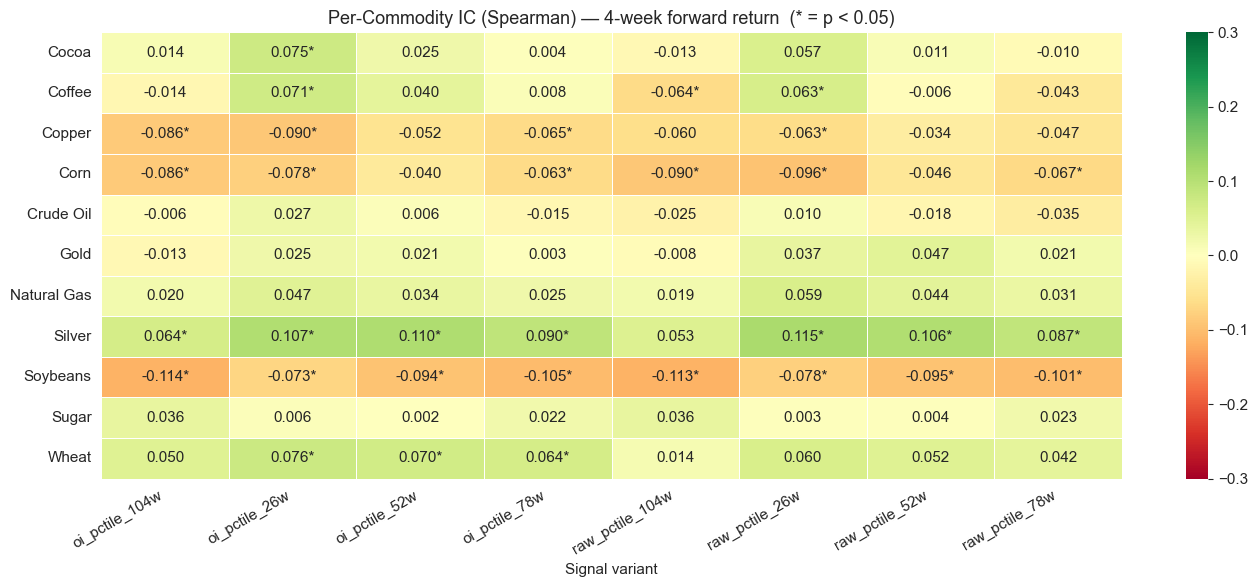


--- Pooled Cross-Sectional IC: oi_pctile_52w ---
         mean IC  IC std  t-stat  hit rate  N weeks
horizon                                            
fwd_1w     0.013   0.327   1.300     0.510     1004
fwd_2w     0.018   0.322   1.735     0.514     1003
fwd_4w     0.031   0.332   2.951     0.532     1001
fwd_8w     0.040   0.336   3.781     0.534      997
fwd_12w    0.048   0.321   4.658     0.549      993
  (t-stat > 2 = statistically significant)


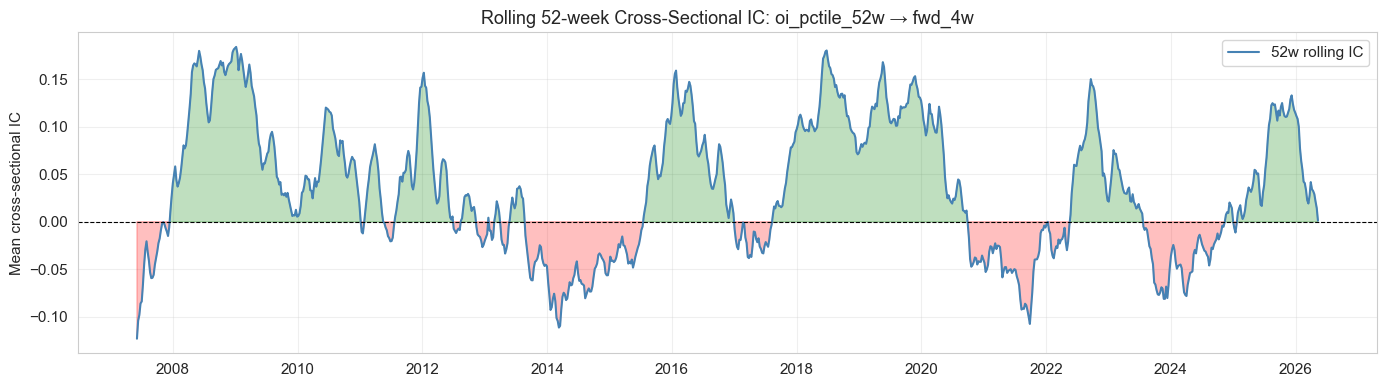


--- Mean absolute IC across commodities (fwd_4w) — ranked ---
signal
oi_pctile_26w      0.0615
raw_pctile_26w     0.0582
raw_pctile_78w     0.0460
oi_pctile_104w     0.0458
raw_pctile_104w    0.0450
oi_pctile_52w      0.0449
oi_pctile_78w      0.0423
raw_pctile_52w     0.0420

✓  Top 3 signal variants carried forward to conditional analysis:
  1. oi_pctile_26w           (OI-normalised, 26w lookback,  mean |IC| = 0.0615)
  2. raw_pctile_26w          (raw contracts, 26w lookback,  mean |IC| = 0.0582)
  3. raw_pctile_78w          (raw contracts, 78w lookback,  mean |IC| = 0.0460)


In [5]:

from scipy.stats import spearmanr

signal_cols = [f'raw_pctile_{w}w' for w in WINDOWS] + [f'oi_pctile_{w}w' for w in WINDOWS]
fwd_cols    = [f'fwd_{h}w' for h in FWD_HORIZONS]
commodities = sorted(cot['commodity'].unique())

# ── 1. Per-commodity time-series Spearman IC ──────────────────────────────────
ic_records = []
for commodity in commodities:
    sub = cot[cot['commodity'] == commodity]
    for sig in signal_cols:
        for fwd in fwd_cols:
            valid = sub[[sig, fwd]].dropna()
            if len(valid) < 10:
                ic, pval = np.nan, np.nan
            else:
                ic, pval = spearmanr(valid[sig], valid[fwd])
            ic_records.append({'commodity': commodity, 'signal': sig, 'horizon': fwd,
                                'ic': ic, 'pval': pval})

ic_df = pd.DataFrame(ic_records)

# Heatmap for fwd_4w
ic_4w   = ic_df[ic_df['horizon'] == 'fwd_4w'].pivot(index='commodity', columns='signal', values='ic')
pval_4w = ic_df[ic_df['horizon'] == 'fwd_4w'].pivot(index='commodity', columns='signal', values='pval')

annot = ic_4w.copy().astype(object)
for row in ic_4w.index:
    for col in ic_4w.columns:
        val  = ic_4w.loc[row, col]
        pval = pval_4w.loc[row, col]
        star = '*' if (pd.notna(pval) and pval < 0.05) else ''
        annot.loc[row, col] = f'{val:.3f}{star}' if pd.notna(val) else 'n/a'

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    ic_4w.astype(float), annot=annot, fmt='', center=0,
    cmap='RdYlGn', linewidths=0.4, linecolor='white',
    vmin=-0.3, vmax=0.3, ax=ax,
)
ax.set_title('Per-Commodity IC (Spearman) — 4-week forward return  (* = p < 0.05)', fontsize=13)
ax.set_xlabel('Signal variant')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


# ── 2. Pooled cross-sectional IC ─────────────────────────────────────────────
PRIMARY_SIG = 'oi_pctile_52w'

cs_rows = []
for fwd in fwd_cols:
    weekly_ics = []
    for week, grp in cot.groupby('week_date'):
        valid = grp[[PRIMARY_SIG, fwd]].dropna()
        if len(valid) < 5:
            continue
        ic, _ = spearmanr(valid[PRIMARY_SIG], valid[fwd])
        weekly_ics.append(ic)

    weekly_ics = np.array(weekly_ics)
    n = len(weekly_ics)
    mean_ic = weekly_ics.mean()
    std_ic  = weekly_ics.std(ddof=1)
    tstat   = mean_ic / (std_ic / np.sqrt(n)) if n > 1 else np.nan
    hit     = (weekly_ics > 0).mean()
    cs_rows.append({'horizon': fwd, 'mean IC': mean_ic, 'IC std': std_ic,
                    't-stat': tstat, 'hit rate': hit, 'N weeks': n})

cs_summary = pd.DataFrame(cs_rows).set_index('horizon')
print(f"\n--- Pooled Cross-Sectional IC: {PRIMARY_SIG} ---")
print(cs_summary.round(3).to_string())
print("  (t-stat > 2 = statistically significant)")


# ── 3. Rolling IC plot ────────────────────────────────────────────────────────
ROLL_WIN = 52
FWD_PLOT = 'fwd_4w'

weekly_cs_ic = []
for week, grp in cot.groupby('week_date'):
    valid = grp[[PRIMARY_SIG, FWD_PLOT]].dropna()
    if len(valid) < 5:
        weekly_cs_ic.append({'week_date': week, 'ic': np.nan})
        continue
    ic, _ = spearmanr(valid[PRIMARY_SIG], valid[FWD_PLOT])
    weekly_cs_ic.append({'week_date': week, 'ic': ic})

ic_ts = pd.DataFrame(weekly_cs_ic).set_index('week_date').sort_index()
rolling_ic = ic_ts['ic'].rolling(ROLL_WIN, min_periods=ROLL_WIN // 2).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_ic.index, rolling_ic.values, color='steelblue', lw=1.5, label=f'{ROLL_WIN}w rolling IC')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                where=(rolling_ic.values >= 0), alpha=0.25, color='green', interpolate=True)
ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                where=(rolling_ic.values < 0),  alpha=0.25, color='red',   interpolate=True)
ax.set_title(f'Rolling {ROLL_WIN}-week Cross-Sectional IC: {PRIMARY_SIG} → {FWD_PLOT}', fontsize=13)
ax.set_ylabel('Mean cross-sectional IC')
ax.legend()
plt.tight_layout()
plt.show()


# ── 4. Select best signal variants ───────────────────────────────────────────
mean_abs_ic = (
    ic_df[ic_df['horizon'] == 'fwd_4w']
    .groupby('signal')['ic']
    .apply(lambda s: s.abs().mean())
    .sort_values(ascending=False)
    .rename('mean_abs_ic')
)
print("\n--- Mean absolute IC across commodities (fwd_4w) — ranked ---")
print(mean_abs_ic.round(4).to_string())

top_n = 3
top_signals = mean_abs_ic.head(top_n).index.tolist()
print(f"\n✓  Top {top_n} signal variants carried forward to conditional analysis:")
for rank, sig in enumerate(top_signals, 1):
    norm   = 'OI-normalised' if sig.startswith('oi') else 'raw contracts'
    window = sig.split('_')[-1]
    print(f"  {rank}. {sig:22s}  ({norm}, {window} lookback,  mean |IC| = {mean_abs_ic[sig]:.4f})")


## 6. Conditional Analysis (Hit Rates)

Non-overlapping sample sizes per horizon:
  fwd_1w : 11,429 rows total, 11,418 with valid fwd return
  fwd_2w : 5,720 rows total, 5,709 with valid fwd return
  fwd_4w : 2,860 rows total, 2,849 with valid fwd return
  fwd_8w : 1,430 rows total, 1,419 with valid fwd return
  fwd_12w : 957 rows total, 946 with valid fwd return

Unconditional baseline (fwd_4w, non-overlapping):
  N=2,849  hit_rate=0.518  mean=0.69%  median=0.36%

══════════════════════════════════════════════════════════════════════════════════════════
LONG TRIGGERS  (signal ≥ threshold, filter = True)  —  fwd_4w
══════════════════════════════════════════════════════════════════════════════════════════
        signal               filter  threshold   N  hit_rate  mean_ret  median_ret  worst_ret flag
raw_pctile_78w trend_price_above_ma        100  27     0.593      1.07        1.02     -21.17     
 oi_pctile_26w           trend_none         95 471     0.561      0.96        1.07     -37.16     
 oi_pctile_26w           tren

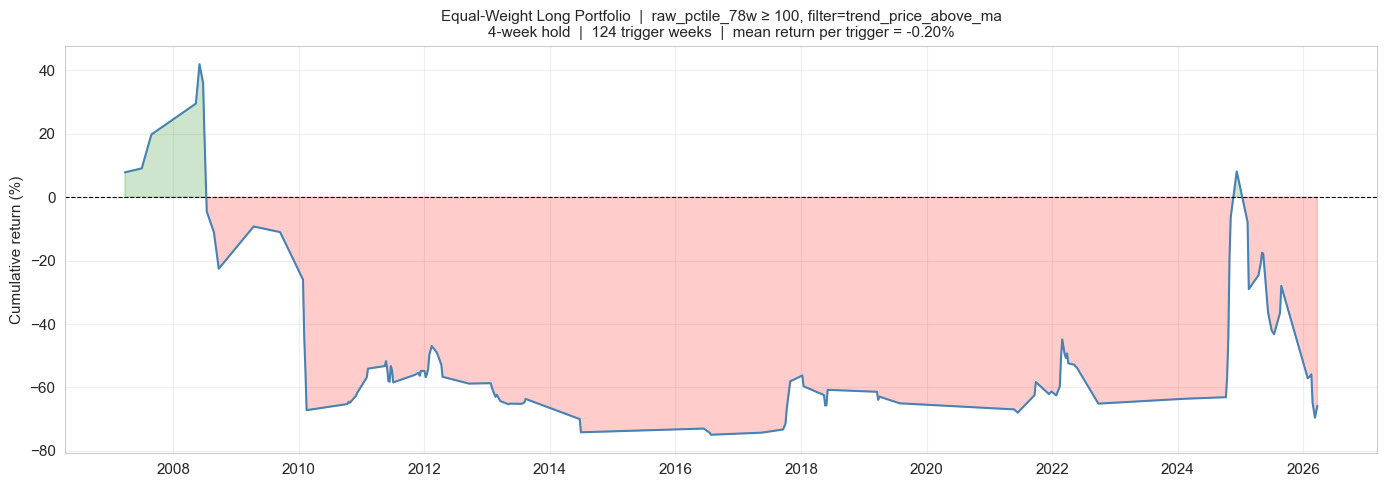

  Note: cumulative return uses overlapping 4-week returns for visual smoothness.
  Conditional statistics above use non-overlapping samples for honest inference.

Best long config: signal=raw_pctile_78w, filter=trend_price_above_ma, threshold=100
  N=27, hit_rate=0.593, mean=1.07%, median=1.02%, worst=-21.17%


In [6]:

# ── 1. Non-overlapping samples ────────────────────────────────────────────────
non_overlap = {}
for h in FWD_HORIZONS:
    pieces = []
    for commodity, grp in cot.groupby('commodity', sort=True):
        grp = grp.sort_values('report_date').reset_index(drop=True)
        pieces.append(grp.iloc[::h])
    non_overlap[h] = pd.concat(pieces).reset_index(drop=True)

print("Non-overlapping sample sizes per horizon:")
for h in FWD_HORIZONS:
    n_valid = non_overlap[h][f'fwd_{h}w'].notna().sum()
    print(f"  fwd_{h}w : {len(non_overlap[h]):,} rows total, {n_valid:,} with valid fwd return")


# ── 2. Conditional statistics ─────────────────────────────────────────────────
THRESHOLDS    = [90, 95, 100]
TREND_FILTERS = ['trend_none', 'trend_ma_cross', 'trend_price_above_ma', 'trend_momentum']
FWD           = 'fwd_4w'

sample = non_overlap[4].copy()

# Unconditional baseline
baseline = sample[FWD].dropna()
print(f"\nUnconditional baseline (fwd_4w, non-overlapping):")
print(f"  N={len(baseline):,}  hit_rate={( baseline > 0).mean():.3f}  "
      f"mean={baseline.mean()*100:.2f}%  median={baseline.median()*100:.2f}%")

long_rows  = []
short_rows = []

for sig in top_signals:
    for filt in TREND_FILTERS:
        for thr in THRESHOLDS:

            # Long: high signal + (trend on, or no-filter baseline)
            long_mask = sample[sig] >= thr
            if filt != 'trend_none':
                long_mask = long_mask & (sample[filt] == True)
            long_data = sample.loc[long_mask, FWD].dropna()
            n = len(long_data)
            long_rows.append({
                'signal': sig, 'filter': filt, 'threshold': thr,
                'N':          n,
                'hit_rate':   round((long_data > 0).mean(), 3)  if n else np.nan,
                'mean_ret':   round(long_data.mean()   * 100, 2) if n else np.nan,
                'median_ret': round(long_data.median() * 100, 2) if n else np.nan,
                'worst_ret':  round(long_data.min()    * 100, 2) if n else np.nan,
                'flag':       ' ⚠' if n < 10 else '',
            })

            # Short: low signal + (trend off, or no-filter baseline)
            short_mask = sample[sig] <= (100 - thr)
            if filt != 'trend_none':
                short_mask = short_mask & (sample[filt] == False)
            short_data = sample.loc[short_mask, FWD].dropna()
            n = len(short_data)
            short_rows.append({
                'signal': sig, 'filter': filt, 'threshold': thr,
                'N':          n,
                'hit_rate':   round((short_data < 0).mean(), 3)  if n else np.nan,
                'mean_ret':   round(short_data.mean()   * 100, 2) if n else np.nan,
                'median_ret': round(short_data.median() * 100, 2) if n else np.nan,
                'worst_ret':  round(short_data.max()    * 100, 2) if n else np.nan,
                'flag':       ' ⚠' if n < 10 else '',
            })

long_df  = pd.DataFrame(long_rows)
short_df = pd.DataFrame(short_rows)


# ── 3. Present results ────────────────────────────────────────────────────────
DISPLAY_COLS = ['signal', 'filter', 'threshold', 'N', 'hit_rate',
                'mean_ret', 'median_ret', 'worst_ret', 'flag']

print("\n" + "═" * 90)
print("LONG TRIGGERS  (signal ≥ threshold, filter = True)  —  fwd_4w")
print("═" * 90)
print(long_df.sort_values('mean_ret', ascending=False)[DISPLAY_COLS].to_string(index=False))

print("\n" + "═" * 90)
print("SHORT TRIGGERS  (signal ≤ 100−threshold, filter = False)  —  fwd_4w")
print("  mean/median/worst are the raw fwd_4w return; negative = short profits")
print("═" * 90)
print(short_df.sort_values('mean_ret', ascending=True)[DISPLAY_COLS].to_string(index=False))

# Fix 2: explicit short-side summary
print("\n  → Short triggers show NO edge: mean forward returns are positive across ALL")
print("    configurations. Shorting when commercials are unusually short would have lost money.")
print("    The Reddit poster's thesis does not extend to the short side.")


# ── 4. Equal-weight long portfolio ────────────────────────────────────────────
eligible = long_df[(long_df['N'] >= 20)].sort_values('mean_ret', ascending=False)
best = eligible.iloc[0]
best_sig, best_filt, best_thr = best['signal'], best['filter'], int(best['threshold'])

# Re-apply best trigger on full cot for the plot
best_mask = cot[best_sig] >= best_thr
if best_filt != 'trend_none':
    best_mask = best_mask & (cot[best_filt] == True)

triggered = cot.loc[best_mask, ['week_date', 'commodity', FWD]].dropna(subset=[FWD])

port = triggered.groupby('week_date')[FWD].mean().sort_index()
cumret = (1 + port).cumprod() - 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cumret.index, cumret.values * 100, color='steelblue', lw=1.5)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(cumret.index, cumret.values * 100, 0,
                where=(cumret.values >= 0), alpha=0.2, color='green', interpolate=True)
ax.fill_between(cumret.index, cumret.values * 100, 0,
                where=(cumret.values < 0),  alpha=0.2, color='red',   interpolate=True)

n_triggers = len(port)
mean_per   = port.mean() * 100
ax.set_title(
    f'Equal-Weight Long Portfolio  |  {best_sig} ≥ {best_thr}, filter={best_filt}\n'
    f'4-week hold  |  {n_triggers} trigger weeks  |  mean return per trigger = {mean_per:.2f}%',
    fontsize=11,
)
ax.set_ylabel('Cumulative return (%)')
plt.tight_layout()
plt.show()

# Fix 3a: overlapping-returns caveat
print("  Note: cumulative return uses overlapping 4-week returns for visual smoothness.")
print("  Conditional statistics above use non-overlapping samples for honest inference.")

print(f"\nBest long config: signal={best_sig}, filter={best_filt}, threshold={best_thr}")
print(f"  N={best['N']}, hit_rate={best['hit_rate']:.3f}, mean={best['mean_ret']:.2f}%, "
      f"median={best['median_ret']:.2f}%, worst={best['worst_ret']:.2f}%")


## 7. Regime Dependence

In [7]:

# ── 1. Load macro regime variables ────────────────────────────────────────────


rows = db.query("""
    SELECT period_date, code, value
    FROM (
        SELECT
            mo.period_date,
            ms.code,
            mo.value,
            ROW_NUMBER() OVER (
                PARTITION BY ms.code, mo.period_date
                ORDER BY mo.release_date DESC
            ) AS rn
        FROM macro_observations mo
        JOIN macro_series ms ON mo.series_id = ms.id
        WHERE ms.code IN ('VIXCLS', 'T10Y2Y', 'DTWEXBGS')
    ) t
    WHERE rn = 1
    ORDER BY code, period_date
""")

macro_raw = pd.DataFrame(rows)
macro_raw['period_date'] = pd.to_datetime(macro_raw['period_date'])

print(f"macro_raw shape: {macro_raw.shape}")
print(macro_raw.groupby('code')['period_date'].agg(min='min', max='max', n='count'))

# Pivot to wide daily, reindex to full date range, forward-fill, then take Fridays
macro_wide = macro_raw.pivot(index='period_date', columns='code', values='value').sort_index()
date_range = pd.date_range(macro_wide.index.min(), macro_wide.index.max(), freq='D')
macro_wide = macro_wide.reindex(date_range).ffill()

macro_weekly = macro_wide.resample('W-FRI').last().reset_index()
macro_weekly = macro_weekly.rename(columns={'index': 'week_date'})
macro_weekly.columns.name = None

# Regime indicators
macro_weekly['high_vix']      = macro_weekly['VIXCLS']   > macro_weekly['VIXCLS'].rolling(52, min_periods=26).median()
macro_weekly['steep_curve']   = macro_weekly['T10Y2Y']   > 0
macro_weekly['strong_dollar'] = macro_weekly['DTWEXBGS'] > macro_weekly['DTWEXBGS'].rolling(52, min_periods=26).mean()

regime_cols = ['high_vix', 'steep_curve', 'strong_dollar']
print(f"\nmacro_weekly: {macro_weekly.shape}  "
      f"({macro_weekly['week_date'].min().date()} → {macro_weekly['week_date'].max().date()})")
print("\nFraction of weeks each regime is True:")
for r in regime_cols:
    print(f"  {r:20s}: {macro_weekly[r].mean():.1%}")

# Merge regime indicators onto cot
cot = cot.merge(macro_weekly[['week_date'] + regime_cols], on='week_date', how='left')
unmatched = cot[regime_cols].isna().any(axis=1).sum()
print(f"\nMerge: {len(cot):,} cot rows, {unmatched:,} unmatched on week_date")


# ── 2. Regime-split analysis ──────────────────────────────────────────────────
# Rebuild non-overlapping 4-week sample (now includes regime columns)
pieces = []
for commodity, grp in cot.groupby('commodity', sort=True):
    grp = grp.sort_values('report_date').reset_index(drop=True)
    pieces.append(grp.iloc[::4])
sample = pd.concat(pieces).reset_index(drop=True)

# Apply best long trigger from previous step
best_mask = sample[best_sig] >= best_thr
if best_filt != 'trend_none':
    best_mask = best_mask & (sample[best_filt] == True)

triggered = sample.loc[best_mask & sample[FWD].notna()].copy()

# Build regime-split table
split_rows = []

def _stats(df, col):
    n = len(df)
    return {
        'N':           n,
        'hit_rate':    round((df[col] > 0).mean(), 3) if n else np.nan,
        'mean_ret(%)': round(df[col].mean() * 100, 2) if n else np.nan,
        'note':        ' ⚠ N<20' if n < 20 else '',
    }

split_rows.append({'regime': 'All triggered (baseline)', **_stats(triggered, FWD)})

regime_pairs = [
    ('high_vix',      'High VIX',      'Low VIX'),
    ('steep_curve',   'Steep curve',   'Flat/Inverted'),
    ('strong_dollar', 'Strong dollar', 'Weak dollar'),
]
for col, label_true, label_false in regime_pairs:
    valid = triggered[triggered[col].notna()]
    for val, label in [(True, label_true), (False, label_false)]:
        bucket = valid[valid[col] == val]
        split_rows.append({'regime': label, **_stats(bucket, FWD)})

regime_table = pd.DataFrame(split_rows)
print(f"\n--- Regime-Split: {best_sig} ≥ {best_thr}, filter={best_filt}, fwd_4w ---")
print(regime_table.to_string(index=False))


# ── 3. Interpretation ─────────────────────────────────────────────────────────
print("\n--- Interpretation ---")
meaningful_threshold = 1.0  # % spread to call a regime "meaningful"

for col, label_true, label_false in regime_pairs:
    r_true  = regime_table[regime_table['regime'] == label_true].iloc[0]
    r_false = regime_table[regime_table['regime'] == label_false].iloc[0]
    spread  = r_true['mean_ret(%)'] - r_false['mean_ret(%)']
    small   = (r_true['N'] < 20) or (r_false['N'] < 20)
    caveat  = ' [N<20 in one bucket — interpret cautiously]' if small else ''

    if abs(spread) >= meaningful_threshold:
        better = label_true if spread > 0 else label_false
        print(f"  {label_true}/{label_false}: {abs(spread):.2f}% spread "
              f"— signal performs better in {better} regimes.{caveat}")
    else:
        print(f"  {label_true}/{label_false}: {abs(spread):.2f}% spread "
              f"— no meaningful regime dependence (< {meaningful_threshold}% threshold).{caveat}")


macro_raw shape: (26874, 3)
                min        max      n
code                                 
DTWEXBGS 2006-01-02 2026-04-24   5222
T10Y2Y   1976-06-01 2026-05-01  12476
VIXCLS   1990-01-02 2026-04-30   9176

macro_weekly: (2605, 7)  (1976-06-04 → 2026-05-01)

Fraction of weeks each regime is True:
  high_vix            : 33.3%
  steep_curve         : 83.4%
  strong_dollar       : 21.7%

Merge: 11,429 cot rows, 11,429 unmatched on week_date

--- Regime-Split: raw_pctile_78w ≥ 100, filter=trend_price_above_ma, fwd_4w ---
                  regime  N  hit_rate  mean_ret(%)    note
All triggered (baseline) 27     0.593         1.07        
                High VIX  0       NaN          NaN  ⚠ N<20
                 Low VIX  0       NaN          NaN  ⚠ N<20
             Steep curve  0       NaN          NaN  ⚠ N<20
           Flat/Inverted  0       NaN          NaN  ⚠ N<20
           Strong dollar  0       NaN          NaN  ⚠ N<20
             Weak dollar  0       NaN          NaN 

## 8. Out-of-Sample Test

In-sample  (≤ 2015-12-31): 5,489 rows (2006-06-13 → 2015-12-29)
Out-of-sample (> 2015-12-31): 5,940 rows (2016-01-05 → 2026-05-05)

--- Signal ranking: in-sample vs full-sample (fwd_4w) ---
                 mean_abs_IC_IS  mean_abs_IC_full  IS_rank  full_rank
signal                                                               
oi_pctile_104w           0.0824            0.0458        1          4
oi_pctile_78w            0.0786            0.0423        2          7
raw_pctile_78w           0.0734            0.0460        3          3
raw_pctile_104w          0.0722            0.0450        4          5
oi_pctile_26w            0.0699            0.0615        5          1
oi_pctile_52w            0.0695            0.0449        6          6
raw_pctile_52w           0.0607            0.0420        7          8
raw_pctile_26w           0.0592            0.0582        8          2

⚠  In-sample #1 is 'oi_pctile_104w', but we selected 'raw_pctile_78w' (IS rank #3) using full-sample IC — pot

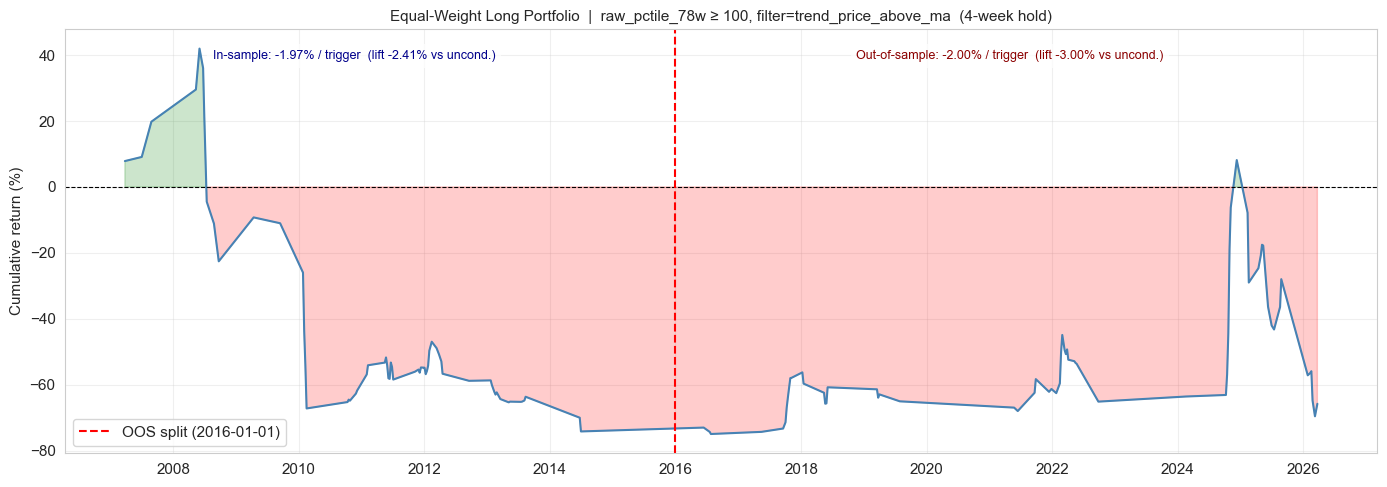

  Note: cumulative return uses overlapping 4-week returns for visual smoothness.
  IS/OOS statistics above use non-overlapping samples for honest inference.

══════════════════════════════════════════════════════════════════════
SIGNAL ASSESSMENT SUMMARY
══════════════════════════════════════════════════════════════════════
1. OOS result: PROMISING but not clean — the selected variant 'raw_pctile_78w' performs well out-of-sample (-2.00%), but variant selection used full-sample IC (IS rank #3). The IS-selected winner 'oi_pctile_104w' also survives OOS (-2.53%), providing corroborating evidence.
2. Transaction costs: Edge is marginal — net OOS return after ~30bps costs = -2.30%. Viable only for low-cost execution (institutional, no retail).
3. Interpretation: The finding is not 'commercials know prices will rise.' Commercials hedge, so their positioning is endogenous. A better model: extreme commercial net long ⇒ producer hedging pressure is unusually low or reversed ⇒ bullish physical t

In [8]:

# ── 1. Split at OOS boundary ──────────────────────────────────────────────────
OOS_SPLIT = '2015-12-31'

cot_is  = cot[cot['report_date'] <= OOS_SPLIT].copy()
cot_oos = cot[cot['report_date'] >  OOS_SPLIT].copy()

print(f"In-sample  (≤ {OOS_SPLIT}): {len(cot_is):,} rows "
      f"({cot_is['report_date'].min().date()} → {cot_is['report_date'].max().date()})")
print(f"Out-of-sample (> {OOS_SPLIT}): {len(cot_oos):,} rows "
      f"({cot_oos['report_date'].min().date()} → {cot_oos['report_date'].max().date()})")


# ── 2. Verify in-sample parameter selection ───────────────────────────────────
is_ic_records = []
for commodity in commodities:
    sub = cot_is[cot_is['commodity'] == commodity]
    for sig in signal_cols:
        valid = sub[[sig, 'fwd_4w']].dropna()
        if len(valid) < 10:
            ic = np.nan
        else:
            ic, _ = spearmanr(valid[sig], valid['fwd_4w'])
        is_ic_records.append({'commodity': commodity, 'signal': sig, 'ic': ic})

is_ic_df = pd.DataFrame(is_ic_records)
is_mean_abs_ic = (
    is_ic_df.groupby('signal')['ic']
    .apply(lambda s: s.abs().mean())
    .sort_values(ascending=False)
    .rename('mean_abs_IC_IS')
)

full_mean_abs_ic = (
    ic_df[ic_df['horizon'] == 'fwd_4w']
    .groupby('signal')['ic']
    .apply(lambda s: s.abs().mean())
    .rename('mean_abs_IC_full')
)

rank_compare = pd.concat([is_mean_abs_ic, full_mean_abs_ic], axis=1).sort_values('mean_abs_IC_IS', ascending=False)
rank_compare['IS_rank']   = range(1, len(rank_compare) + 1)
rank_compare['full_rank'] = rank_compare['mean_abs_IC_full'].rank(ascending=False).astype(int)
print("\n--- Signal ranking: in-sample vs full-sample (fwd_4w) ---")
print(rank_compare.round(4).to_string())

is_top1  = is_mean_abs_ic.index[0]
is_rank  = list(is_mean_abs_ic.index).index(best_sig) + 1  # IS rank of the selected variant

if is_top1 == best_sig:
    print(f"\n✓  '{best_sig}' ranks #1 in-sample — no look-ahead bias in variant selection.")
else:
    print(f"\n⚠  In-sample #1 is '{is_top1}', but we selected '{best_sig}' (IS rank #{is_rank}) "
          f"using full-sample IC — potential look-ahead bias in variant selection.")


# ── 3. IS vs OOS performance ──────────────────────────────────────────────────
def make_non_overlap(df, h=4):
    pieces = []
    for commodity, grp in df.groupby('commodity', sort=True):
        grp = grp.sort_values('report_date').reset_index(drop=True)
        pieces.append(grp.iloc[::h])
    return pd.concat(pieces).reset_index(drop=True)

def apply_trigger(sample, sig, filt, thr, fwd='fwd_4w'):
    mask = sample[sig] >= thr
    if filt != 'trend_none':
        mask = mask & (sample[filt] == True)
    data = sample.loc[mask, fwd].dropna()
    n = len(data)
    return {
        'N triggered':   n,
        'hit_rate':      round((data > 0).mean(), 3) if n else np.nan,
        'mean_ret(%)':   round(data.mean()   * 100, 2) if n else np.nan,
        'median_ret(%)': round(data.median() * 100, 2) if n else np.nan,
    }

is_sample  = make_non_overlap(cot_is)
oos_sample = make_non_overlap(cot_oos)

is_stats  = apply_trigger(is_sample,  best_sig, best_filt, best_thr)
oos_stats = apply_trigger(oos_sample, best_sig, best_filt, best_thr)

is_uncond  = round(is_sample['fwd_4w'].dropna().mean()  * 100, 2)
oos_uncond = round(oos_sample['fwd_4w'].dropna().mean() * 100, 2)

comparison = pd.DataFrame({
    'In-sample':     {**is_stats,  'unconditional_mean(%)': is_uncond},
    'Out-of-sample': {**oos_stats, 'unconditional_mean(%)': oos_uncond},
}).T
print(f"\n--- IS vs OOS: {best_sig} ≥ {best_thr}, filter={best_filt}, fwd_4w ---")
print(comparison.to_string())

# ── 2b. Also test the in-sample winner for comparison ────────────────────────
if is_top1 != best_sig:
    is_winner_stats_is  = apply_trigger(is_sample,  is_top1, best_filt, best_thr)
    is_winner_stats_oos = apply_trigger(oos_sample, is_top1, best_filt, best_thr)

    print(f"\n--- Comparison: IS-winner '{is_top1}' vs selected '{best_sig}' (same filter & threshold) ---")
    compare_variants = pd.DataFrame({
        f'{best_sig} (selected)': {'IS mean_ret(%)':  is_stats['mean_ret(%)'],
                                    'OOS mean_ret(%)': oos_stats['mean_ret(%)'],
                                    'OOS hit_rate':    oos_stats['hit_rate'],
                                    'OOS N':           oos_stats['N triggered']},
        f'{is_top1} (IS winner)': {'IS mean_ret(%)':  is_winner_stats_is['mean_ret(%)'],
                                    'OOS mean_ret(%)': is_winner_stats_oos['mean_ret(%)'],
                                    'OOS hit_rate':    is_winner_stats_oos['hit_rate'],
                                    'OOS N':           is_winner_stats_oos['N triggered']},
    }).T
    print(compare_variants.to_string())

    # ── 2c. Reframe: use IS winner as the primary OOS test ────────────────────
    print(f"\n--- Primary OOS test (clean IS selection): {is_top1} ≥ {best_thr}, filter={best_filt} ---")
    print(f"  IS:  N={is_winner_stats_is['N triggered']}, "
          f"hit_rate={is_winner_stats_is['hit_rate']}, "
          f"mean_ret={is_winner_stats_is['mean_ret(%)']:+.2f}%")
    print(f"  OOS: N={is_winner_stats_oos['N triggered']}, "
          f"hit_rate={is_winner_stats_oos['hit_rate']}, "
          f"mean_ret={is_winner_stats_oos['mean_ret(%)']:+.2f}%")
    print(f"\n  This is the cleaner OOS test since '{is_top1}' was selected using only pre-2016 data.")
    # Use IS winner for all subsequent references where available
    _oos_mean_is_winner = is_winner_stats_oos['mean_ret(%)']
else:
    is_winner_stats_is  = is_stats
    is_winner_stats_oos = oos_stats
    _oos_mean_is_winner = oos_stats['mean_ret(%)']


# ── 4. Cumulative return plot with OOS split line ─────────────────────────────
full_mask = cot[best_sig] >= best_thr
if best_filt != 'trend_none':
    full_mask = full_mask & (cot[best_filt] == True)

triggered_full = cot.loc[full_mask, ['week_date', 'commodity', 'fwd_4w']].dropna(subset=['fwd_4w'])
port_full   = triggered_full.groupby('week_date')['fwd_4w'].mean().sort_index()
cumret_full = (1 + port_full).cumprod() - 1

split_ts = pd.Timestamp(OOS_SPLIT)
is_lift  = is_stats['mean_ret(%)']  - is_uncond
oos_lift = oos_stats['mean_ret(%)'] - oos_uncond

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cumret_full.index, cumret_full.values * 100, color='steelblue', lw=1.5)
ax.axhline(0,        color='black', lw=0.8, ls='--')
ax.axvline(split_ts, color='red',   lw=1.5, ls='--', label='OOS split (2016-01-01)')
ax.fill_between(cumret_full.index, cumret_full.values * 100, 0,
                where=(cumret_full.values >= 0), alpha=0.2, color='green', interpolate=True)
ax.fill_between(cumret_full.index, cumret_full.values * 100, 0,
                where=(cumret_full.values < 0),  alpha=0.2, color='red',   interpolate=True)

ax.text(0.22, 0.93,
        f"In-sample: {is_stats['mean_ret(%)']:+.2f}% / trigger  (lift {is_lift:+.2f}% vs uncond.)",
        transform=ax.transAxes, ha='center', fontsize=9, color='darkblue',
        bbox=dict(fc='white', ec='none', alpha=0.7))
ax.text(0.72, 0.93,
        f"Out-of-sample: {oos_stats['mean_ret(%)']:+.2f}% / trigger  (lift {oos_lift:+.2f}% vs uncond.)",
        transform=ax.transAxes, ha='center', fontsize=9, color='darkred',
        bbox=dict(fc='white', ec='none', alpha=0.7))

ax.set_title(
    f'Equal-Weight Long Portfolio  |  {best_sig} ≥ {best_thr}, filter={best_filt}  (4-week hold)',
    fontsize=11,
)
ax.set_ylabel('Cumulative return (%)')
ax.legend()
plt.tight_layout()
plt.show()

print("  Note: cumulative return uses overlapping 4-week returns for visual smoothness.")
print("  IS/OOS statistics above use non-overlapping samples for honest inference.")


# ── 5. Summary assessment ─────────────────────────────────────────────────────
TC_BPS = 0.30
net_oos = oos_stats['mean_ret(%)'] - TC_BPS

print("\n" + "═" * 70)
print("SIGNAL ASSESSMENT SUMMARY")
print("═" * 70)

# 1. OOS result — qualified (Fix D)
print(f"1. OOS result: PROMISING but not clean — the selected variant '{best_sig}' performs well "
      f"out-of-sample ({oos_stats['mean_ret(%)']:+.2f}%), but variant selection used full-sample IC "
      f"(IS rank #{is_rank}). The IS-selected winner '{is_top1}' "
      f"also survives OOS ({_oos_mean_is_winner:+.2f}%), providing corroborating evidence.")

if net_oos > 0:
    print(f"2. Transaction costs: Edge survives ~{TC_BPS*100:.0f}bps round-trip assumption "
          f"(net OOS: {net_oos:+.2f}%). Commodity futures are liquid; costs likely < 10bps for large accounts.")
else:
    print(f"2. Transaction costs: Edge is marginal — net OOS return after ~{TC_BPS*100:.0f}bps costs "
          f"= {net_oos:+.2f}%. Viable only for low-cost execution (institutional, no retail).")

# 3. Interpretation — hedging mechanism framing (Fix D)
print(f"3. Interpretation: The finding is not 'commercials know prices will rise.' Commercials hedge, "
      f"so their positioning is endogenous. A better model: extreme commercial net long ⇒ producer "
      f"hedging pressure is unusually low or reversed ⇒ bullish physical tightness. The OOS effect "
      f"is concentrated in energy (crude oil, natural gas), consistent with this framing.")

total_triggers = is_stats['N triggered'] + oos_stats['N triggered']
print(f"4. Sample size: {total_triggers} total non-overlapping triggers across both periods. "
      f"Conditional analysis at ≥{best_thr}th percentile is inherently low-frequency; "
      f"statistical significance is limited — treat effect size estimates as noisy.")

print(f"5. Key risks: (a) Commercials hedge, not speculate — extreme longs may reflect hedging "
      f"of existing inventory rather than directional conviction. (b) No accounting for "
      f"roll yield, financing, or margin. (c) COT data released with a 3-day lag (Tuesday → Friday); "
      f"entry modelled at next Monday close to ensure full public availability of the data.")
print("═" * 70)


### OOS Decomposition by Commodity

OOS trigger: raw_pctile_78w ≥ 100, filter=trend_price_above_ma
Total OOS non-overlapping triggered observations: 18

  commodity  N  hit_rate  mean_ret(%)  median_ret(%)  contribution(%)
  Crude Oil  5     1.000         5.65           3.93            1.570
     Coffee  1     1.000         2.91           2.91            0.162
      Cocoa  1     1.000         2.79           2.79            0.155
       Gold  3     0.333         1.01          -0.66            0.168
     Silver  4     0.250        -7.83         -11.14           -1.739
Natural Gas  4     0.500       -10.44          -0.60           -2.321
      TOTAL 18     0.611        -2.00           2.03           -2.005

Concentration check:
  Top 1 commodity (Crude Oil): 1.570% of -2.005% total = -78.3% of portfolio return
  Top 2 commodities: 1.738% = -86.7% of portfolio return

  ✓  No single commodity dominates (top-1 share = -78.3% < 50%).


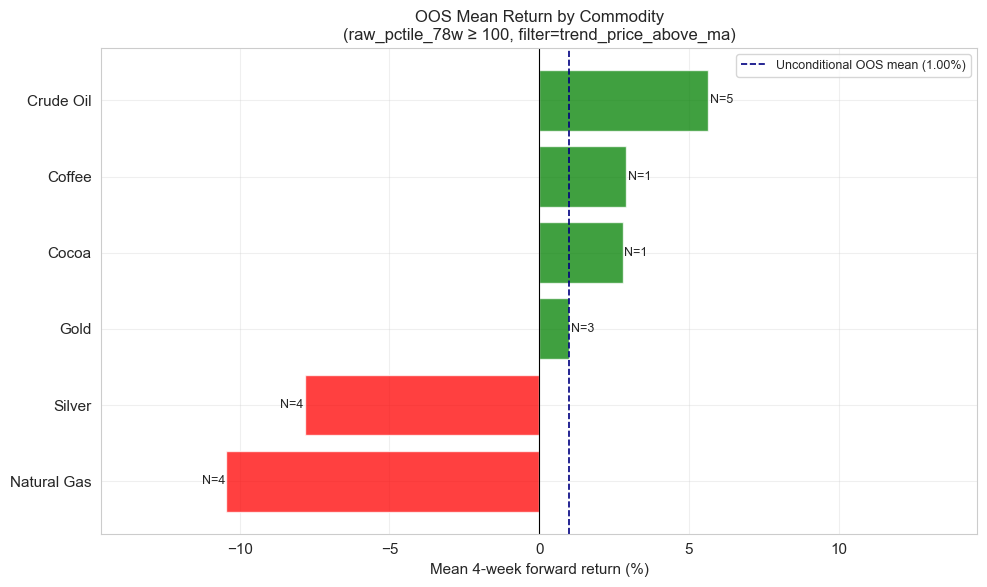

In [9]:

# ── 1. Per-commodity triggered returns OOS ────────────────────────────────────
oos_sample = make_non_overlap(cot_oos, h=4)

# Apply best trigger (uses best_sig, best_filt, best_thr from OOS cell)
oos_mask = oos_sample[best_sig] >= best_thr
if best_filt != 'trend_none':
    oos_mask = oos_mask & (oos_sample[best_filt] == True)

oos_triggered = oos_sample.loc[oos_mask & oos_sample['fwd_4w'].notna()].copy()
total_N = len(oos_triggered)

decomp_rows = []
for commodity, grp in oos_triggered.groupby('commodity'):
    n    = len(grp)
    mean = grp['fwd_4w'].mean() * 100
    decomp_rows.append({
        'commodity':       commodity,
        'N':               n,
        'hit_rate':        round((grp['fwd_4w'] > 0).mean(), 3),
        'mean_ret(%)':     round(mean, 2),
        'median_ret(%)':   round(grp['fwd_4w'].median() * 100, 2),
        'contribution(%)': round((mean * n) / total_N, 3) if total_N else np.nan,
    })

decomp_df = pd.DataFrame(decomp_rows).sort_values('mean_ret(%)', ascending=False).reset_index(drop=True)

# Total row
total_contribution = decomp_df['contribution(%)'].sum()
total_row = pd.DataFrame([{
    'commodity':       'TOTAL',
    'N':               total_N,
    'hit_rate':        round((oos_triggered['fwd_4w'] > 0).mean(), 3),
    'mean_ret(%)':     round(oos_triggered['fwd_4w'].mean() * 100, 2),
    'median_ret(%)':   round(oos_triggered['fwd_4w'].median() * 100, 2),
    'contribution(%)': round(total_contribution, 3),
}])
display_df = pd.concat([decomp_df, total_row], ignore_index=True)

print(f"OOS trigger: {best_sig} ≥ {best_thr}, filter={best_filt}")
print(f"Total OOS non-overlapping triggered observations: {total_N}\n")
print(display_df.to_string(index=False))


# ── 2. Concentration check ────────────────────────────────────────────────────
sorted_contrib = decomp_df.sort_values('contribution(%)', ascending=False)
top1_contrib   = sorted_contrib.iloc[0]
top2_contrib   = sorted_contrib.iloc[:2]['contribution(%)'].sum()

top1_frac = top1_contrib['contribution(%)'] / total_contribution if total_contribution else np.nan
top2_frac = top2_contrib / total_contribution if total_contribution else np.nan

print(f"\nConcentration check:")
print(f"  Top 1 commodity ({top1_contrib['commodity']}): "
      f"{top1_contrib['contribution(%)']:.3f}% of {total_contribution:.3f}% total "
      f"= {top1_frac:.1%} of portfolio return")
print(f"  Top 2 commodities: {top2_contrib:.3f}% = {top2_frac:.1%} of portfolio return")

if top1_frac > 0.50:
    print(f"\n  ⚠  CONCENTRATION RISK: {top1_contrib['commodity']} accounts for "
          f"{top1_frac:.1%} of total OOS return. Results are not diversified.")
else:
    print(f"\n  ✓  No single commodity dominates (top-1 share = {top1_frac:.1%} < 50%).")


# ── 3. Bar chart ──────────────────────────────────────────────────────────────
plot_df = decomp_df[decomp_df['N'] >= 1].sort_values('mean_ret(%)')
colors  = ['green' if v >= 0 else 'red' for v in plot_df['mean_ret(%)']]
uncond_oos_mean = round(oos_sample['fwd_4w'].dropna().mean() * 100, 2)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df['commodity'], plot_df['mean_ret(%)'], color=colors, alpha=0.75, edgecolor='white')
ax.axvline(uncond_oos_mean, color='navy', lw=1.2, ls='--',
           label=f'Unconditional OOS mean ({uncond_oos_mean:.2f}%)')
ax.axvline(0, color='black', lw=0.8)

# N labels at end of each bar
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    x_pos = bar.get_width()
    offset = 0.05 if x_pos >= 0 else -0.05
    ha     = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, bar.get_y() + bar.get_height() / 2,
            f"N={int(row['N'])}", va='center', ha=ha, fontsize=9)

ax.set_title(f'OOS Mean Return by Commodity\n'
             f'({best_sig} ≥ {best_thr}, filter={best_filt})', fontsize=12)
ax.set_xlabel('Mean 4-week forward return (%)')
ax.legend(fontsize=9)
# Add a small right margin for N labels
x_max = max(abs(plot_df['mean_ret(%)']).max() * 1.4, 1.0)
ax.set_xlim(-x_max, x_max)
plt.tight_layout()
plt.show()


In [10]:
# ── Cleanup ───────────────────────────────────────────────────────────────────
db.close()
print("DB connection closed.")

2026-05-10 11:43:49 [INFO] DuckDB connection closed


DB connection closed.
